In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

plt.rcdefaults()
plt.style.use('seaborn-v0_8-paper')
plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica']})

from ttcrpy.rgrid import Grid2d

# Example Grid2d (OpenCL) – Comparing CPU and GPU Fast-Sweeping Method in 2D

This notebook demonstrates the OpenCL GPU-accelerated implementation of the
Fast-Sweeping Method (FSM) for 2D rectilinear grids and compares it against
the regular CPU implementation.

Two classes are covered:

| `cell_slowness` | CPU class | GPU class |
|---|---|---|
| `True` | `Grid2Drcfs` | `Grid2Drcfs_OpenCL` |
| `False` | `Grid2Drnfs` | `Grid2Drnfs_OpenCL` |

Both are selected transparently through the `Grid2d` factory by passing
`method='FSM'` and `fsm_gpu=True`.  The `dtype=np.float32` argument is used
throughout because many GPUs (Apple Silicon, integrated GPUs) do not support
`cl_khr_fp64`.  When double precision is requested on such a device, the grid
silently falls back to CPU, so the GPU path would never actually run.

## Model

A 2D section with five horizontal layers of linearly increasing velocity
(1 km/s at the surface, 3 km/s at the bottom).  The grid has 200 × 100 cells
of 10 m × 10 m.

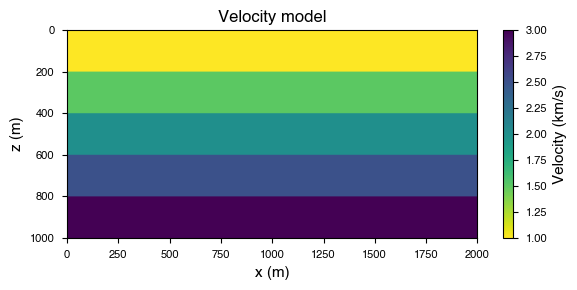

In [2]:
Nx, Nz = 2000, 1000   # number of cells in x and z
dx = dz = 1.0      # cell size in metres

# Node coordinates (Nx+1 and Nz+1 nodes)
xn = np.arange(0, (Nx + 1) * dx, dx, dtype=np.float32)
zn = np.arange(0, (Nz + 1) * dz, dz, dtype=np.float32)

# Five-layer velocity model (cell centres, z increases downward)
v_layers = [1.0, 1.5, 2.0, 2.5, 3.0]   # km/s
layer_thickness = Nz // len(v_layers)    # cells per layer

vel_1d = np.empty(Nz, dtype=np.float32)
for k, v in enumerate(v_layers):
    vel_1d[k * layer_thickness : (k + 1) * layer_thickness] = v

# Tile across all x columns → shape (Nx * Nz,), z-fast (ttcrpy convention)
slowness_cells = np.tile(1.0 / vel_1d, Nx).astype(np.float32)

# Node slowness: average of surrounding cell slownesses
# We build a (Nz,) profile at nodes from the (Nz,) cell profile
s_cell_2d = (1.0 / vel_1d)                       # shape (Nz,)
s_node_1d = np.empty(Nz + 1, dtype=np.float32)
s_node_1d[0]    = s_cell_2d[0]
s_node_1d[-1]   = s_cell_2d[-1]
s_node_1d[1:-1] = 0.5 * (s_cell_2d[:-1] + s_cell_2d[1:])
slowness_nodes = np.tile(s_node_1d, Nx + 1).astype(np.float32)

# Quick sanity plot
fig, ax = plt.subplots(figsize=(6, 3))
ax.imshow(vel_1d[np.newaxis, :].T.repeat(Nx, axis=1),
          extent=[0, Nx * dx, Nz * dz, 0],
          aspect='auto', cmap='viridis_r')
cb = plt.colorbar(ax.images[0], ax=ax)
cb.set_label('Velocity (km/s)', fontsize=11)
ax.set_xlabel('x (m)', fontsize=11)
ax.set_ylabel('z (m)', fontsize=11)
ax.set_title('Velocity model', fontsize=12)
plt.tight_layout()
plt.show()

## Source and receiver geometry

One source at the surface centre and receivers spread along the surface.

In [3]:
src = np.array([[Nx * dx / 2, 5.0]], dtype=np.float32)   # (x, z)

# Receivers every 20 m along the surface, avoiding the source column
rcv_x = np.arange(dx, Nx * dx, 20.0, dtype=np.float32)
rcv_z = np.full_like(rcv_x, 5.0)
rcv   = np.column_stack([rcv_x, rcv_z])

---
## Part 1 – Cell slowness (`Grid2Drcfs` / `Grid2Drcfs_OpenCL`)

When `cell_slowness=True`, slowness values are attached to grid *cells*.
The CPU path uses `Grid2Drcfs`; the GPU path uses `Grid2Drcfs_OpenCL`.

In [4]:
# ── CPU ──────────────────────────────────────────────────────────────────────
grid_rc_cpu = Grid2d(xn, zn, cell_slowness=True, method='FSM',
                     weno=True, fsm_gpu=False, dtype=np.float32)
grid_rc_cpu.set_slowness(slowness_cells)

t0 = time.perf_counter()
tt_rc_cpu = grid_rc_cpu.raytrace(src, rcv)
time_rc_cpu = time.perf_counter() - t0
print(f'Grid2Drcfs  (CPU) – {time_rc_cpu:.3f} s')

Grid2Drcfs  (CPU) – 10.093 s


In [5]:
# ── GPU ──────────────────────────────────────────────────────────────────────
grid_rc_gpu = Grid2d(xn, zn, cell_slowness=True, method='FSM',
                     weno=True, fsm_gpu=True, dtype=np.float32)
grid_rc_gpu.set_slowness(slowness_cells)

# Warm-up: first call compiles the OpenCL kernels
_ = grid_rc_gpu.raytrace(src, rcv)

t0 = time.perf_counter()
tt_rc_gpu = grid_rc_gpu.raytrace(src, rcv)
time_rc_gpu = time.perf_counter() - t0
print(f'Grid2Drcfs_OpenCL (GPU) – {time_rc_gpu:.3f} s')

Grid2Drcfs_OpenCL (GPU) – 2.042 s


---
## Part 2 – Node slowness (`Grid2Drnfs` / `Grid2Drnfs_OpenCL`)

When `cell_slowness=False`, slowness values live at grid *nodes*.
The CPU path uses `Grid2Drnfs`; the GPU path uses `Grid2Drnfs_OpenCL`.

In [6]:
# ── CPU ──────────────────────────────────────────────────────────────────────
grid_rn_cpu = Grid2d(xn, zn, cell_slowness=False, method='FSM',
                     weno=True, fsm_gpu=False, dtype=np.float32)
grid_rn_cpu.set_slowness(slowness_nodes)

t0 = time.perf_counter()
tt_rn_cpu = grid_rn_cpu.raytrace(src, rcv)
time_rn_cpu = time.perf_counter() - t0
print(f'Grid2Drnfs  (CPU) – {time_rn_cpu:.3f} s')

Grid2Drnfs  (CPU) – 10.095 s


In [7]:
# ── GPU ──────────────────────────────────────────────────────────────────────
grid_rn_gpu = Grid2d(xn, zn, cell_slowness=False, method='FSM',
                     weno=True, fsm_gpu=True, dtype=np.float32)
grid_rn_gpu.set_slowness(slowness_nodes)

# Warm-up
_ = grid_rn_gpu.raytrace(src, rcv)

t0 = time.perf_counter()
tt_rn_gpu = grid_rn_gpu.raytrace(src, rcv)
time_rn_gpu = time.perf_counter() - t0
print(f'Grid2Drnfs_OpenCL (GPU) – {time_rn_gpu:.3f} s')

Grid2Drnfs_OpenCL (GPU) – 2.072 s


---
## Results

CPU and GPU traveltimes should be essentially identical; any tiny differences
reflect the different floating-point operation order on the GPU.

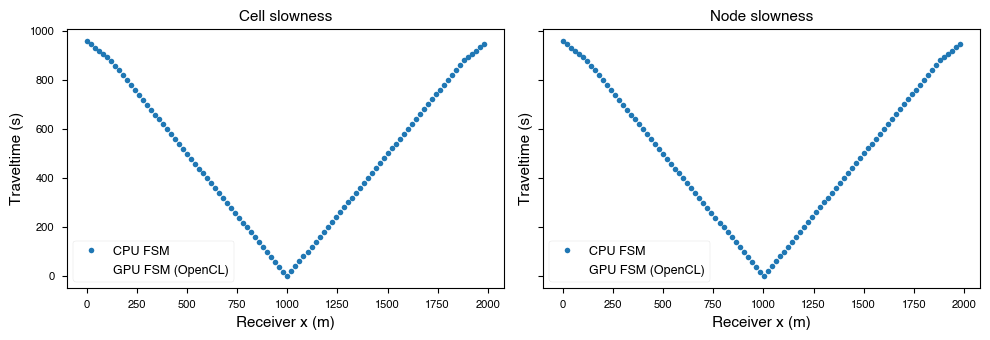

Drcfs  max |CPU – GPU| = 1.953e-03   L2 = 6.409e-03
Drnfs  max |CPU – GPU| = 1.953e-03   L2 = 6.409e-03


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

for ax, tt_cpu, tt_gpu, title in zip(
        axes,
        [tt_rc_cpu, tt_rn_cpu],
        [tt_rc_gpu, tt_rn_gpu],
        ['Cell slowness', 'Node slowness']):
    ax.plot(rcv_x, tt_cpu, 'o', ms=4, label='CPU FSM')
    ax.plot(rcv_x, tt_gpu, '+', ms=6, label='GPU FSM (OpenCL)')
    ax.set_xlabel('Receiver x (m)', fontsize=11)
    ax.set_ylabel('Traveltime (s)', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

for name, tt_cpu, tt_gpu in [
        ('Drcfs', tt_rc_cpu, tt_rc_gpu),
        ('Drnfs', tt_rn_cpu, tt_rn_gpu)]:
    diff = np.abs(tt_cpu - tt_gpu)
    print(f'{name}  max |CPU – GPU| = {diff.max():.3e}   '
          f'L2 = {np.linalg.norm(diff):.3e}')

In [9]:
print('Compute times (post warm-up)\n')
print(f'  Grid2Drcfs  CPU : {time_rc_cpu:.3f} s')
print(f'  Grid2Drcfs  GPU : {time_rc_gpu:.3f} s   '
      f'speed-up {time_rc_cpu / time_rc_gpu:.1f}x')
print()
print(f'  Grid2Drnfs  CPU : {time_rn_cpu:.3f} s')
print(f'  Grid2Drnfs  GPU : {time_rn_gpu:.3f} s   '
      f'speed-up {time_rn_cpu / time_rn_gpu:.1f}x')

Compute times (post warm-up)

  Grid2Drcfs  CPU : 10.093 s
  Grid2Drcfs  GPU : 2.042 s   speed-up 4.9x

  Grid2Drnfs  CPU : 10.095 s
  Grid2Drnfs  GPU : 2.072 s   speed-up 4.9x


## Full traveltime field

We can also inspect the entire traveltime field saved by `saveTT` – but the
simplest way from Python is to call `raytrace` with a dense receiver grid
and reshape the result.

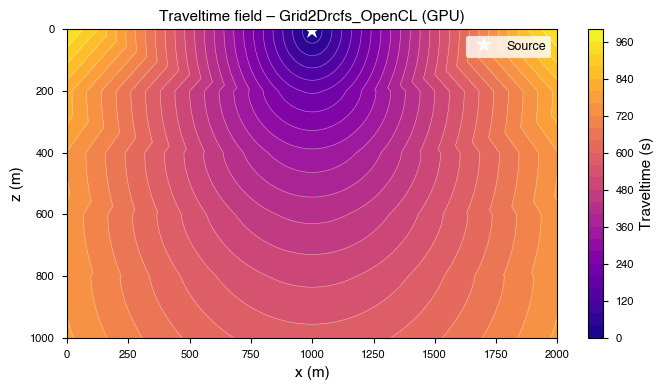

In [10]:
# Build a dense receiver grid at every node
xi, zi = np.meshgrid(xn, zn, indexing='ij')
rcv_all = np.column_stack([xi.ravel(), zi.ravel()]).astype(np.float32)

tt_field = grid_rc_gpu.raytrace(src, rcv_all).reshape(Nx + 1, Nz + 1)

fig, ax = plt.subplots(figsize=(7, 4))
cf = ax.contourf(xn, zn, tt_field.T, levels=30, cmap='plasma')
ax.contour(xn, zn, tt_field.T, levels=30, colors='w', linewidths=0.4, alpha=0.5)
cb = plt.colorbar(cf, ax=ax)
cb.set_label('Traveltime (s)', fontsize=11)
ax.plot(src[0, 0], src[0, 1], 'w*', ms=12, label='Source')
ax.set_xlabel('x (m)', fontsize=11)
ax.set_ylabel('z (m)', fontsize=11)
ax.set_title('Traveltime field – Grid2Drcfs_OpenCL (GPU)', fontsize=11)
ax.invert_yaxis()
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()